# SEABORN WORK NOTEBOOK
---
### Where i will be showcasing my work in seaborn i would be taking a data generated by api which deals with weather related stuff i would not be publishing .env file contain api code including api key due to obvious reason

> This is api link https://meteostat.p.rapidapi.com/point/monthly used to generate weather data set! 

this code is also present at my kaggle profile : https://www.kaggle.com/thedhawalpanchamiya 

If someone feels to use it you make use it by 


```
Install dependencies as needed:
pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

Set the path to the file you'd like to load
file_path = ""

 Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "thedhawalpanchamiya/weather-data-set",
  file_path,
   Provide any additional arguments like 
   sql_query or pandas_kwargs. See the 
   documenation for more information:
  https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())



> It contains weather report of coordinates "lat":"52.5244","lon":"13.4105" from date jan - 2020 to dec - 2025

---

### Lets start with importing lib needed

In [128]:
import numpy as np
import pandas as pd 
import seaborn as sns
import scipy as spy
import sklearn as skl

--- 

### After importing Lib, Now lets load data in dataframe


In [129]:
data = pd.read_csv("weather_data.csv")
data.head()

,date,tavg,tmin,tmax,prcp,wspd,pres,tsun
0,2020-01-01,4.6,2.4,6.8,49.0,NaN,1021.1,3678
1,2020-02-01,6.3,4.0,8.6,89.2,NaN,1010.0,2820
2,2020-03-01,5.7,2.1,9.5,47.6,NaN,1017.8,9966
3,2020-04-01,10.7,5.2,16.3,7.7,NaN,1018.4,17754
4,2020-05-01,12.3,7.3,16.7,26.9,NaN,1019.3,13554


---

### Lets have a quick look at data if needeed we will be dealing be preprocessing as well

In [130]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    72 non-null     str    
 1   tavg    72 non-null     float64
 2   tmin    72 non-null     float64
 3   tmax    72 non-null     float64
 4   prcp    72 non-null     float64
 5   wspd    0 non-null      float64
 6   pres    72 non-null     float64
 7   tsun    72 non-null     int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 4.6 KB


In this data we have one complete column thats empty we can remove it

In [131]:
data = data.drop(columns = ["wspd"])

In [132]:
data.head()

,date,tavg,tmin,tmax,prcp,pres,tsun
0,2020-01-01,4.6,2.4,6.8,49.0,1021.1,3678
1,2020-02-01,6.3,4.0,8.6,89.2,1010.0,2820
2,2020-03-01,5.7,2.1,9.5,47.6,1017.8,9966
3,2020-04-01,10.7,5.2,16.3,7.7,1018.4,17754
4,2020-05-01,12.3,7.3,16.7,26.9,1019.3,13554


so we have succesfully removed wspd from this data

---
### Now Lets began with other required stuff

-DISTRIBUTION ANALYSIS-

> Q1 Plot the distribution of average temperature (tavg) using a histogram

<Axes: xlabel='tavg', ylabel='Count'>

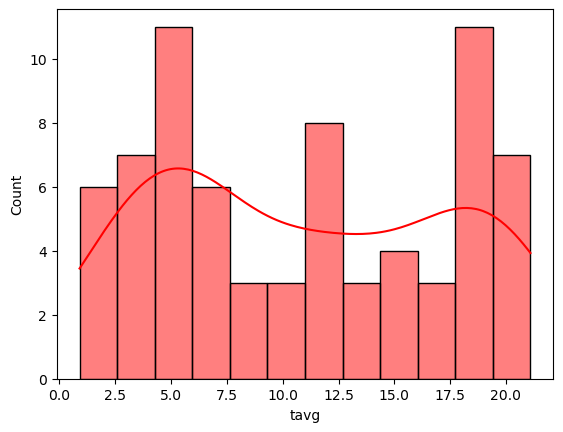

In [133]:
sns.histplot(data=data,x= data["tavg"],color="red",bins = 12,kde = True)

From this we observe a trend of 1.25 - 7.5 looks good in number after that it decreases and again increases around 17.5 - 20.0

> Q2 Compare distributions of tavg, tmin, and tmax.

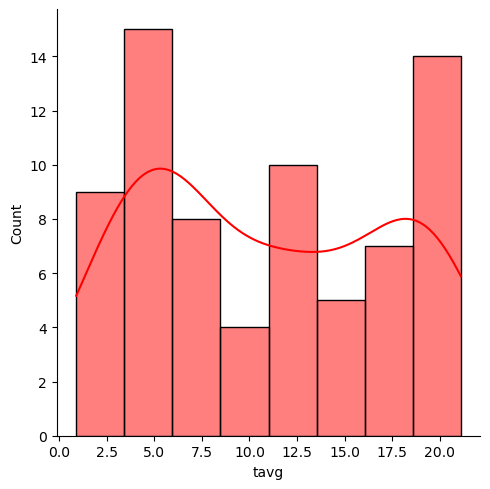

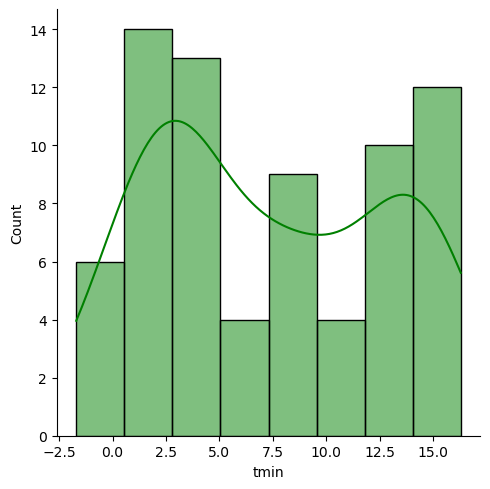

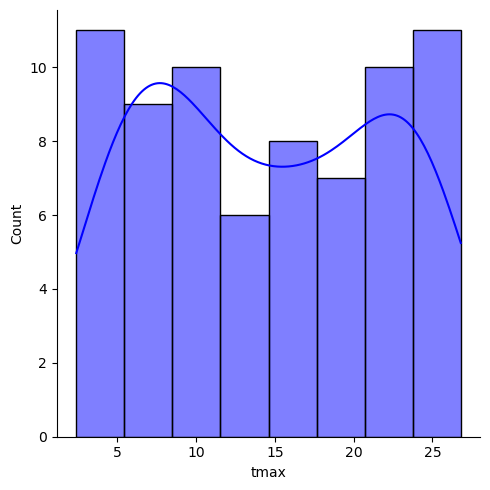

In [134]:
sns.displot(data=data, x="tavg", color="red", kde=True)
sns.displot(data=data, x="tmin", color="green", kde=True)
sns.displot(data=data, x="tmax", color="blue", kde=True)

<Axes: xlabel='tavg', ylabel='Density'>

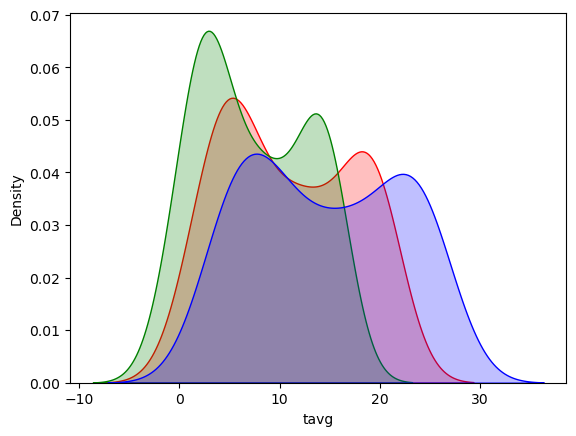

In [135]:
sns.kdeplot(data=data, x="tavg", color="red", label="Average" , fill = True)
sns.kdeplot(data=data, x="tmin", color="green", label="Minimum", fill = True)
sns.kdeplot(data=data, x="tmax", color="blue", label="Maximum", fill = True)

> Q3 Visualize rainfall (prcp) distribution and identify whether it is skewed.

<Axes: xlabel='prcp', ylabel='Density'>

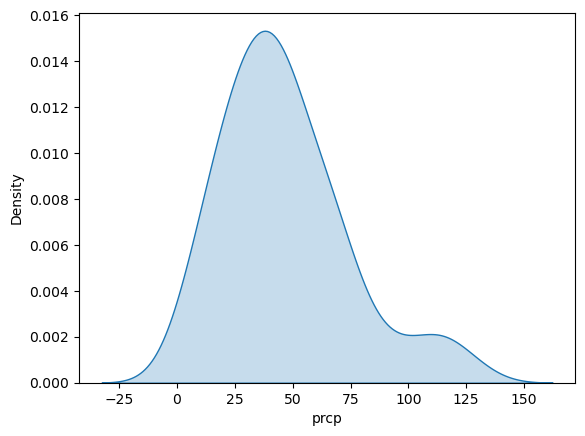

In [136]:
sns.kdeplot(data=data, x="prcp", fill=True)

<Axes: xlabel='prcp'>

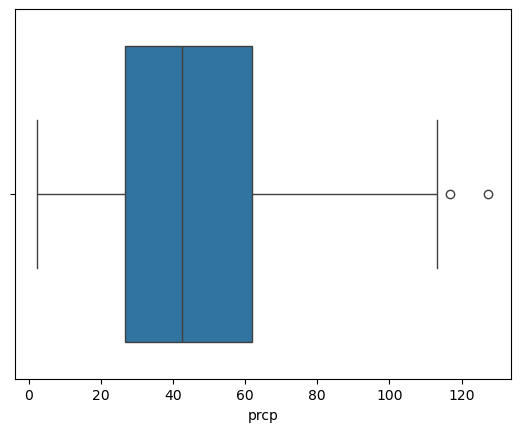

In [137]:
sns.boxplot(data=data, x="prcp")

In [138]:
data["prcp"].skew()

np.float64(0.9668837566958123)

Rainfall (prcp) exhibits a positive skewness of 0.967, indicating a right-skewed distribution. Most observations correspond to low precipitation levels, while a small number of days experience significantly higher rainfall, resulting in a long right tail.

> Q4 Create boxplots for all numerical columns and identify outliers.

for this kind for work we need matplotlib subplot element:

In [139]:
import matplotlib.pyplot as plt

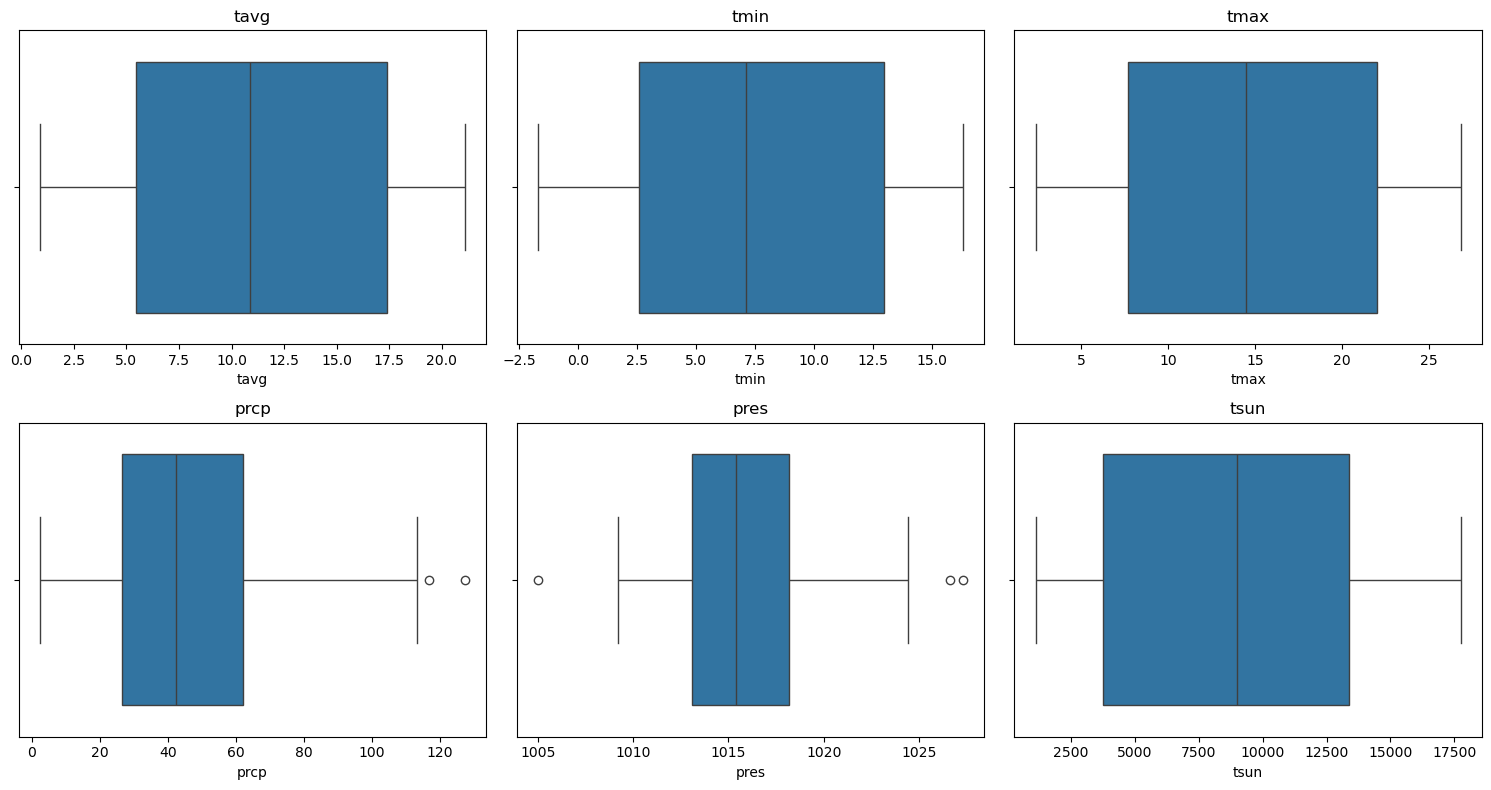

In [140]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), data.select_dtypes(include="number").columns):
    sns.boxplot(x=data[col], ax=ax )
    ax.set_title(col)

plt.tight_layout()

for outliers we need 25%ile - (1.5 * 75%ile - 25%ile) as lower bound and 75%ile + 1.5 * (75%ile - 25%ile) , this is termed as IQR Method

In [141]:
num_cols = data.select_dtypes(include="number").columns

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()

    print(f"{col}: {n_outliers} outliers")

tavg: 0 outliers
tmin: 0 outliers
tmax: 0 outliers
prcp: 2 outliers
pres: 3 outliers
tsun: 0 outliers


---
Time Series Trends

> Q5 How does average temperature change over time?

<Axes: xlabel='date', ylabel='tavg'>

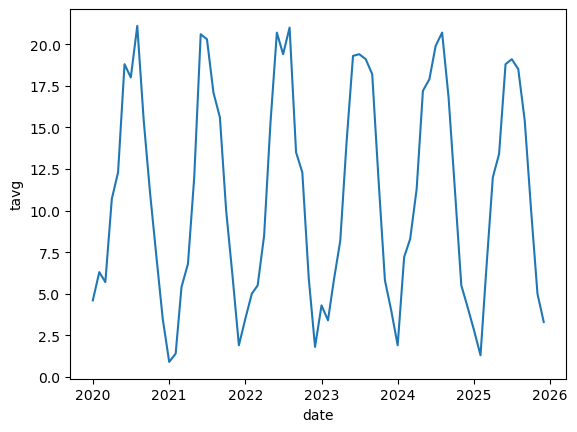

In [142]:
data["date"] = pd.to_datetime(data["date"])

sns.lineplot(data=data, x="date", y="tavg")

We observe regular ups and downs in this data

> Q6. Plot minimum and maximum temperatures together over time.

<Axes: xlabel='date', ylabel='tmin'>

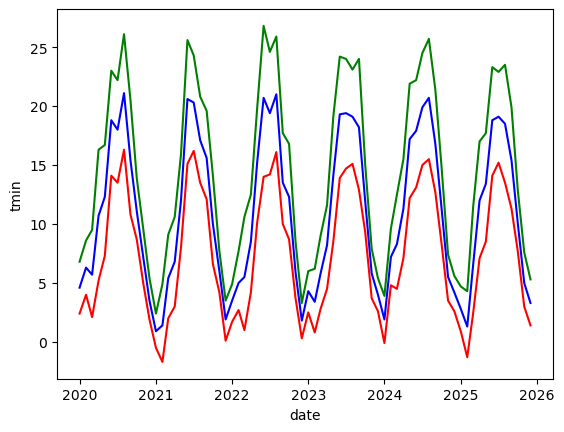

In [143]:
sns.lineplot(data = data , x = "date" , y = "tmin" , color = "red")
sns.lineplot(data = data , x = "date" , y = "tmax" , color = "green")
sns.lineplot(data = data , x = "date" , y = "tavg" , color = "blue")

> q7 Visualize sunshine duration (tsun) over the years.

<Axes: xlabel='date', ylabel='tsun'>

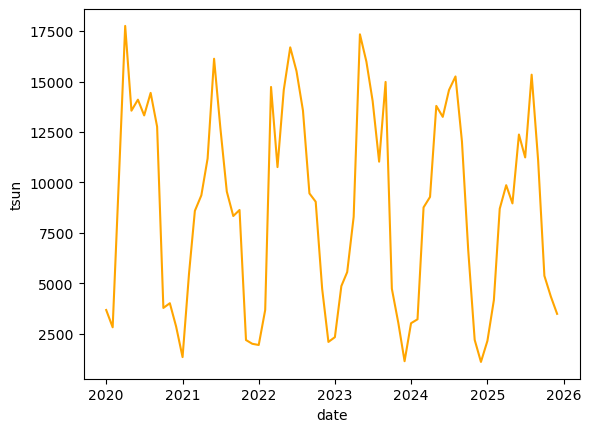

In [144]:
sns.lineplot(data = data, x = "date", y = "tsun", color = "orange")

> Q8. How does atmospheric pressure (pres) vary over time?

<Axes: xlabel='date', ylabel='pres'>

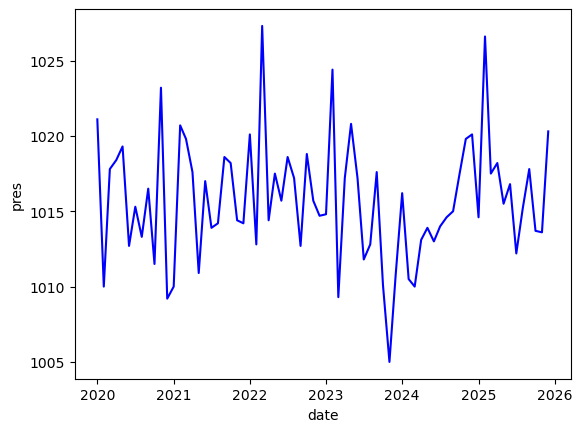

In [145]:
sns.lineplot(data= data, x = "date",y = "pres",color = "blue")

---
-RELATIONSHIP BTWN VARIABLES-
> Q9 is there a relationship btwn temperature and sunshine duration

<Axes: xlabel='tavg', ylabel='tsun'>

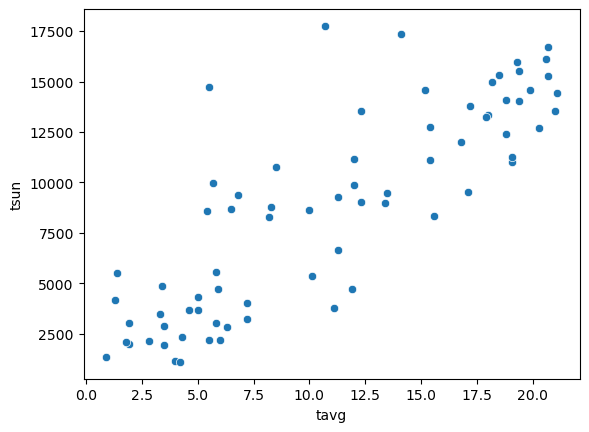

In [146]:
sns.scatterplot(data=data, x="tavg", y="tsun")

<Axes: xlabel='tavg', ylabel='tsun'>

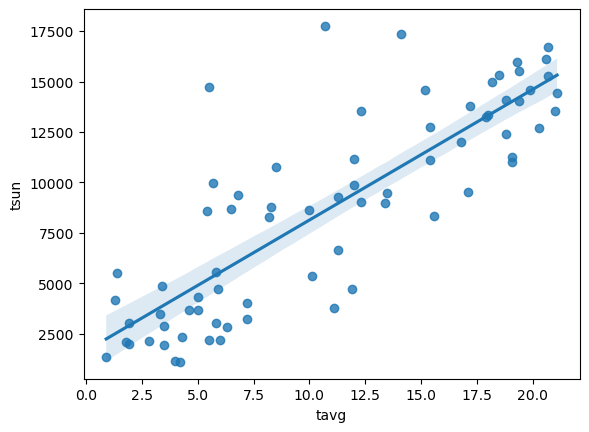

In [147]:
sns.regplot(data=data, x="tavg", y="tsun")

<Axes: xlabel='tavg', ylabel='tsun'>

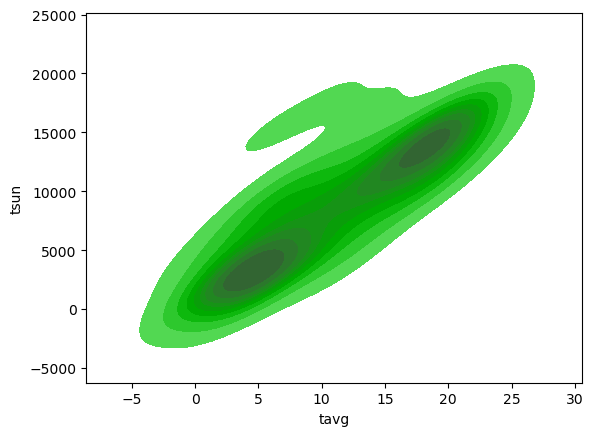

In [148]:
sns.kdeplot(data=data, x="tavg", y="tsun", fill=True,color = "green")

> Q10) Does rainfall affect average temperature?

<Axes: xlabel='tavg', ylabel='prcp'>

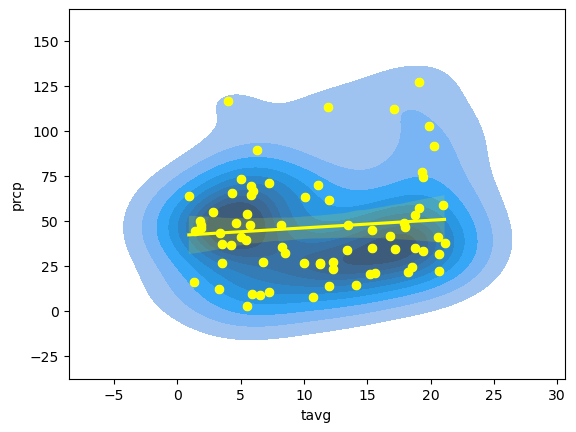

In [149]:
# for this lets use relationship plots btwn them:
sns.kdeplot(data = data, x= "tavg",y="prcp", fill= "red")

sns.scatterplot(data = data, x= "tavg",y="prcp", color = "yellow")
sns.regplot(data = data, x= "tavg",y="prcp", color = "yellow")

> q11 Analyze the relationship between temperature and pressure.

<Axes: xlabel='tavg', ylabel='pres'>

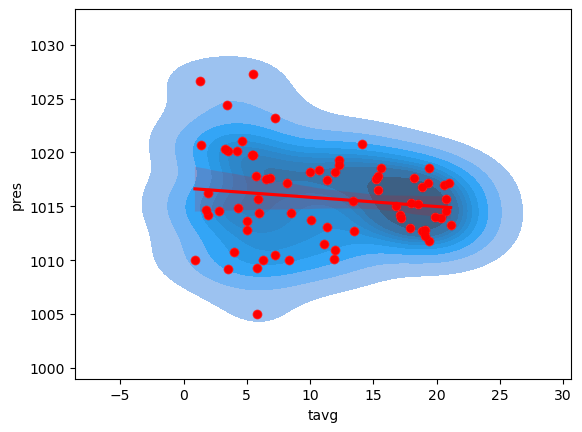

In [150]:
sns.kdeplot(data = data, x= "tavg",y="pres", fill= "blue")
sns.scatterplot(data = data, x= "tavg",y="pres", color = "red")
sns.regplot(data = data, x= "tavg",y="pres", color = "red")

> Q12 Does sunshine duration increase maximum temperature?

In [151]:
data["date"] = pd.to_datetime(data["date"])
data["year"] = data["date"].dt.year
data["year"]

0     2020
1     2020
2     2020
3     2020
4     2020
      ... 
67    2025
68    2025
69    2025
70    2025
71    2025
Name: year, Length: 72, dtype: int32

<Axes: xlabel='tmax', ylabel='tsun'>

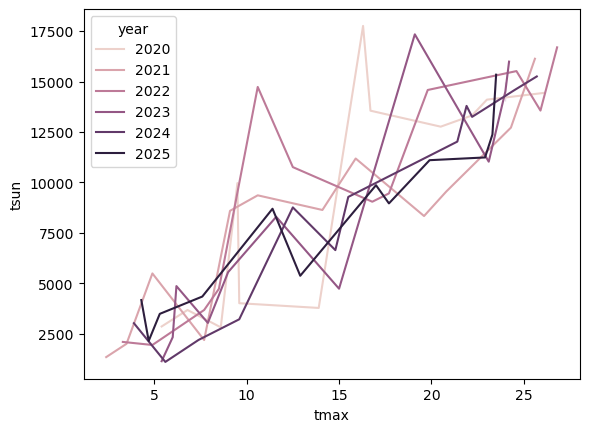

In [152]:

sns.lineplot(data = data , x = "tmax" , y = "tsun" , hue = "year" )

> Q14 Create regression plots between:

 - tavg vs tmax
 - tavg vs tmin
 - tsun vs tavg

<Axes: xlabel='tavg', ylabel='tmin'>

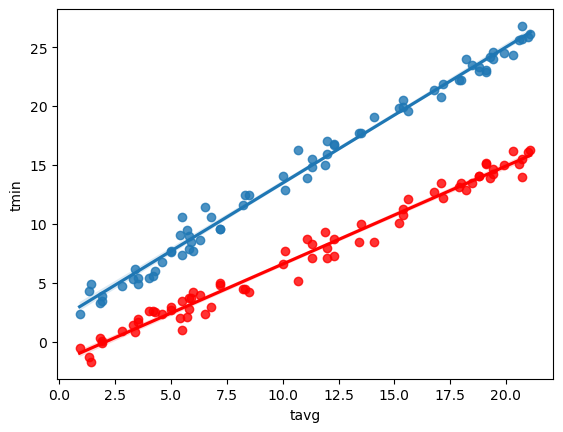

In [153]:
sns.regplot(data = data, x = "tavg" ,  y = "tmax")
sns.regplot(data = data, x = "tavg" ,  y = "tmin" , color = "red")

<Axes: xlabel='tavg', ylabel='tsun'>

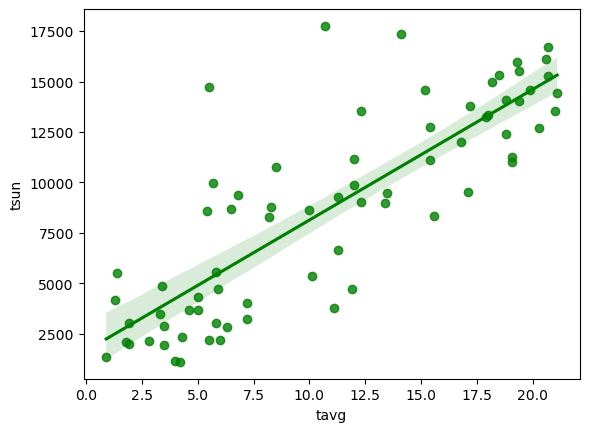

In [154]:
sns.regplot(data = data, y_jitter= False, y= "tsun" ,  x = "tavg", color = "green")

---
-CORRELATION ANALYSIS-

Q14.

Compute and visualize the correlation matrix.

<Axes: >

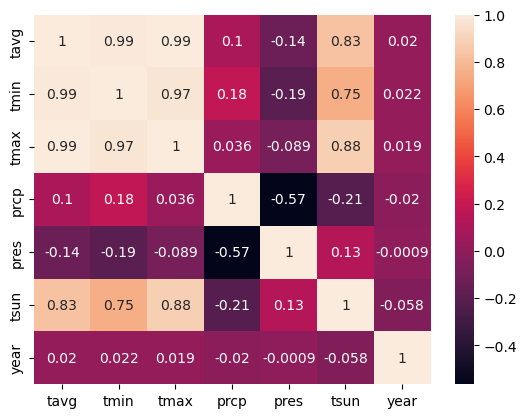

In [155]:
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

> Q15 Which weather variables are most strongly correlated with average temperature?

avg temp mostly coorelates with min and max temp then with tsun 

> q16 Identify positive and negative correlations among all variables.

In [156]:
corr = data.corr(numeric_only=True)

for i in range(len(corr.columns)):
    for j in range(i):
        col1 = corr.columns[i]
        col2 = corr.columns[j]
        value = corr.iloc[i, j]

        if value > 0:
            print(f"{col1} and {col2}: Positive correlation ({value:.2f})")
        elif value < 0:
            print(f"{col1} and {col2}: Negative correlation ({value:.2f})")

tmin and tavg: Positive correlation (0.99)
tmax and tavg: Positive correlation (0.99)
tmax and tmin: Positive correlation (0.97)
prcp and tavg: Positive correlation (0.10)
prcp and tmin: Positive correlation (0.18)
prcp and tmax: Positive correlation (0.04)
pres and tavg: Negative correlation (-0.14)
pres and tmin: Negative correlation (-0.19)
pres and tmax: Negative correlation (-0.09)
pres and prcp: Negative correlation (-0.57)
tsun and tavg: Positive correlation (0.83)
tsun and tmin: Positive correlation (0.75)
tsun and tmax: Positive correlation (0.88)
tsun and prcp: Negative correlation (-0.21)
tsun and pres: Positive correlation (0.13)
year and tavg: Positive correlation (0.02)
year and tmin: Positive correlation (0.02)
year and tmax: Positive correlation (0.02)
year and prcp: Negative correlation (-0.02)
year and pres: Negative correlation (-0.00)
year and tsun: Negative correlation (-0.06)


## Correlation Analysis

### Temperature Variables

- **Average temperature (`tavg`) and minimum temperature (`tmin`)** exhibit a **strong positive correlation (0.99)**, indicating that days with higher average temperatures tend to have higher minimum temperatures.

- **Average temperature (`tavg`) and maximum temperature (`tmax`)** also show a **strong positive correlation (0.99)**.

- **Minimum temperature (`tmin`) and maximum temperature (`tmax`)** are strongly positively correlated (**0.97**).

> **Inference:** The temperature variables are highly related and provide similar information about the thermal conditions.

### Rainfall (`prcp`)

- Rainfall shows only weak positive correlations with temperature variables:
  - `prcp` – `tavg`: **0.10**
  - `prcp` – `tmin`: **0.18**
  - `prcp` – `tmax`: **0.04**

> **Inference:** Precipitation appears to have little linear relationship with temperature.

### Atmospheric Pressure (`pres`)

- Pressure exhibits weak negative correlations with temperature:
  - `pres` – `tavg`: **-0.14**
  - `pres` – `tmin`: **-0.19**
  - `pres` – `tmax`: **-0.09**

- Pressure and rainfall show a **moderate negative correlation (-0.57)**.

> **Inference:** Lower atmospheric pressure is generally associated with increased rainfall.

### Sunshine Duration (`tsun`)

- Sunshine duration has strong positive correlations with temperature variables:
  - `tsun` – `tavg`: **0.83**
  - `tsun` – `tmin`: **0.75**
  - `tsun` – `tmax`: **0.88**

- Sunshine duration and rainfall exhibit a weak negative correlation (**-0.21**).

> **Inference:** Longer sunshine duration is associated with warmer temperatures, whereas rainy days generally receive less sunlight.

### Temporal Trend (`year`)

Correlations between year and weather variables are close to zero:

- `year` – `tavg`: **0.02**
- `year` – `tmin`: **0.02**
- `year` – `tmax`: **0.02**
- `year` – `prcp`: **-0.02**
- `year` – `pres`: **-0.00**
- `year` – `tsun`: **-0.06**

> **Inference:** No significant long-term trend is observed in the dataset over the years considered.

## Key Findings

- Temperature variables (`tavg`, `tmin`, and `tmax`) exhibit very strong positive correlations.
- Maximum temperature (`tmax`) and sunshine duration (`tsun`) have a strong positive association (**0.88**).
- Atmospheric pressure and precipitation show a moderate negative correlation (**-0.57**), suggesting rainfall is associated with lower pressure systems.
- Sunshine duration tends to decrease on rainy days.
- No noticeable climatic trend is evident across the years represented in the dataset.

---
-Pairwise Analysis-
> Q17 Create a pairplot for all numerical variables.

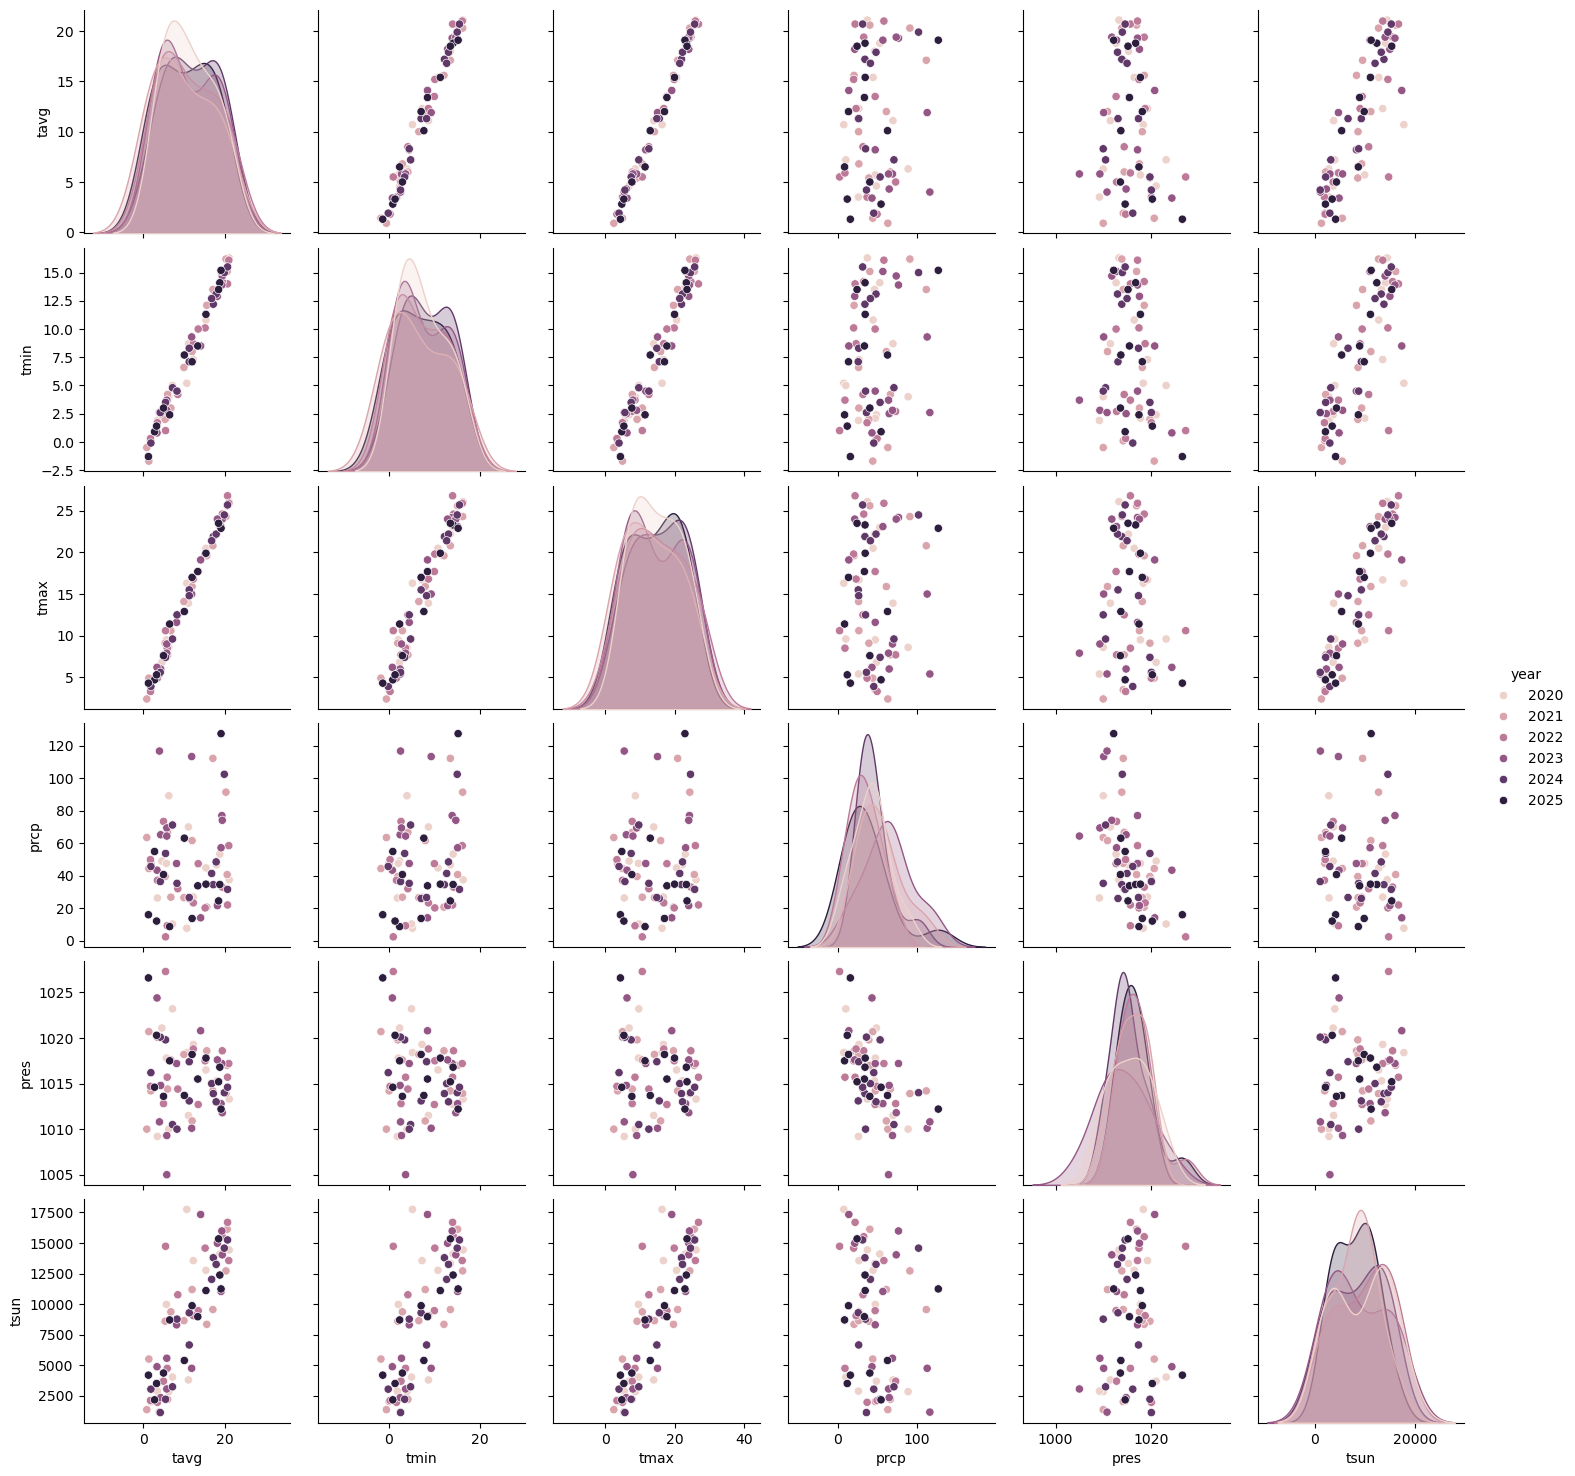

In [157]:
sns.pairplot(data = data, hue = "year")

> Q18. Which pairs of variables appear to have linear relationships?

## Linear Relationships Between Variables

From the pair plots and correlation analysis, the following pairs exhibit noticeable linear relationships:

### Strong Positive Linear Relationships

- **Average Temperature (`tavg`) vs Minimum Temperature (`tmin`)**
  - Correlation coefficient: **0.99**
  - Shows an almost perfect positive linear relationship.

- **Average Temperature (`tavg`) vs Maximum Temperature (`tmax`)**
  - Correlation coefficient: **0.99**
  - Indicates that average temperature increases proportionally with maximum temperature.

- **Minimum Temperature (`tmin`) vs Maximum Temperature (`tmax`)**
  - Correlation coefficient: **0.97**
  - Displays a strong positive linear association.

- **Sunshine Duration (`tsun`) vs Maximum Temperature (`tmax`)**
  - Correlation coefficient: **0.88**
  - Higher sunshine duration is associated with higher maximum temperatures.

- **Sunshine Duration (`tsun`) vs Average Temperature (`tavg`)**
  - Correlation coefficient: **0.83**
  - Warmer days generally experience longer periods of sunshine.

- **Sunshine Duration (`tsun`) vs Minimum Temperature (`tmin`)**
  - Correlation coefficient: **0.75**
  - Indicates a moderately strong positive linear relationship.

### Negative Linear Relationships

- **Atmospheric Pressure (`pres`) vs Precipitation (`prcp`)**
  - Correlation coefficient: **-0.57**
  - Lower atmospheric pressure tends to coincide with higher rainfall.

### Weak or Negligible Relationships

The following variable pairs exhibit weak or no apparent linear relationship:

- `prcp` vs `tavg` (**0.10**)
- `prcp` vs `tmin` (**0.18**)
- `prcp` vs `tmax` (**0.04**)
- `pres` vs `tavg` (**-0.14**)
- `pres` vs `tmin` (**-0.19**)
- `pres` vs `tmax` (**-0.09**)
- `tsun` vs `prcp` (**-0.21**)
- Weather variables vs `year` (**≈ 0**)

> **Inference:** Temperature variables exhibit strong positive linear relationships among themselves and with sunshine duration, whereas atmospheric pressure and precipitation show a moderate inverse relationship. Most other variable pairs do not demonstrate a significant linear trend.

---

-SEASONAL ANAYSIS-

> Q19 which month has avg temp.?

In [158]:
data["date"] = pd.to_datetime(data["date"])
data["month"] = data["date"].dt.month
data["month"]

0      1
1      2
2      3
3      4
4      5
      ..
67     8
68     9
69    10
70    11
71    12
Name: month, Length: 72, dtype: int32

<Axes: xlabel='month', ylabel='tavg'>

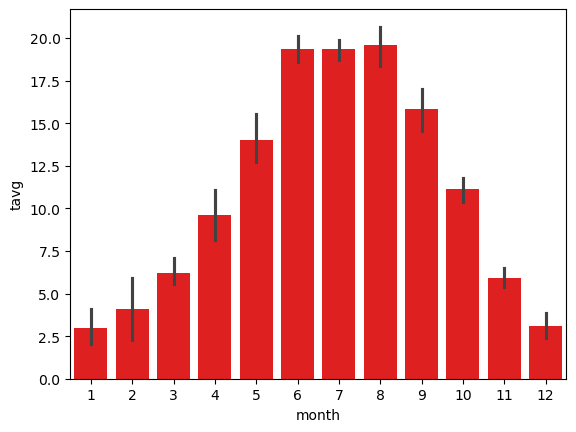

In [159]:
sns.barplot(data = data , x= "month" , y = "tavg" , color = "red")

> Q20 which month recieved most rainfall

<Axes: xlabel='month', ylabel='prcp'>

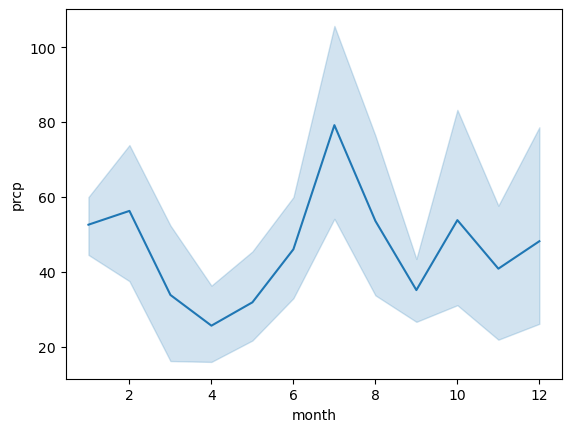

In [160]:
sns.lineplot(data = data , x= "month" , y = "prcp")

> Q21.
> Compare monthly sunshine duration.

<Axes: xlabel='month', ylabel='tsun'>

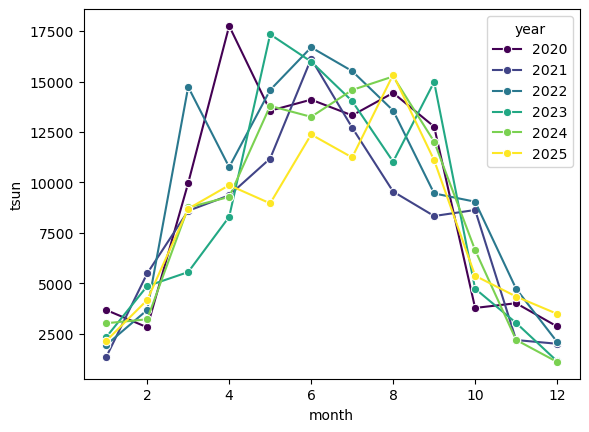

In [161]:
sns.lineplot(data = data, x = "month" , y = "tsun" , hue ="year" , palette= "viridis", marker = "o" )

> Q22.Create boxplots of average temperature for each month.

/tmp/ipykernel_8703/505091063.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data , x = "month" , y = "tavg" ,palette="magma")


<Axes: xlabel='month', ylabel='tavg'>

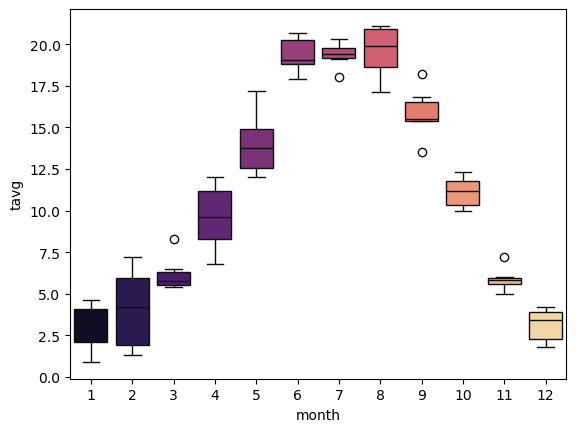

In [162]:
sns.boxplot(data = data , x = "month" , y = "tavg" ,palette="magma")

> q23 Which month shows the greatest temperature variability?

In [163]:
monthly_std = data.groupby("month")["tavg"].std().sort_values(ascending=False)

print(monthly_std)

month
2     2.485156
4     2.042955
5     1.945936
8     1.620391
9     1.575331
1     1.425482
6     1.104083
3     1.099091
12    1.034247
10    0.930412
7     0.786766
11    0.732120
Name: tavg, dtype: float64


## Monthly Temperature Variability

Monthly boxplots and standard deviations of average temperature (`tavg`) were used to assess temperature variability throughout the year.

### Observations

- **February (Month 2)** exhibits the greatest temperature variability, with a standard deviation of **2.49°C**.
- **April (Month 4)** and **May (Month 5)** also show relatively high variability, with standard deviations of **2.04°C** and **1.95°C**, respectively.
- **November (Month 11)** and **July (Month 7)** have the lowest variability, with standard deviations of **0.73°C** and **0.79°C**, indicating more stable temperatures.
- The larger spread in February suggests greater fluctuations in average temperature during this month.

> **Inference:** February shows the highest temperature variability among all months, indicating significant day-to-day temperature fluctuations. In contrast, July and November exhibit relatively stable temperatures with minimal variation.

---
-Advance Questions-


```
Use a jointplot to study the relationship between:

tavg and tsun
prcp and tavg
```

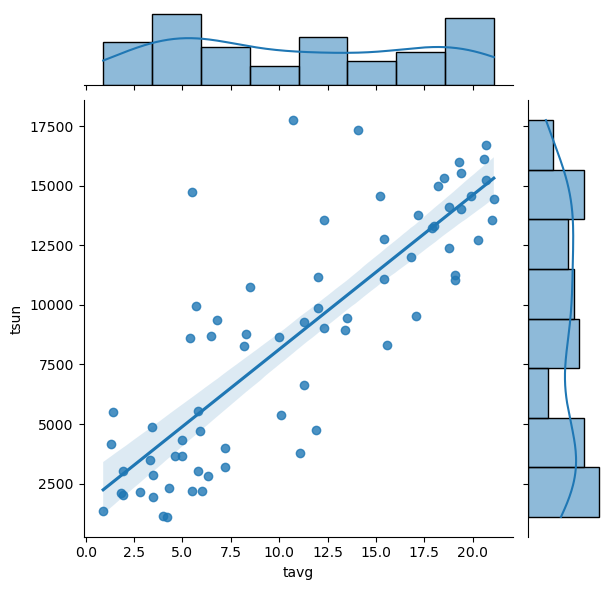

In [164]:
sns.jointplot(data=data, x="tavg", y="tsun", kind="reg")

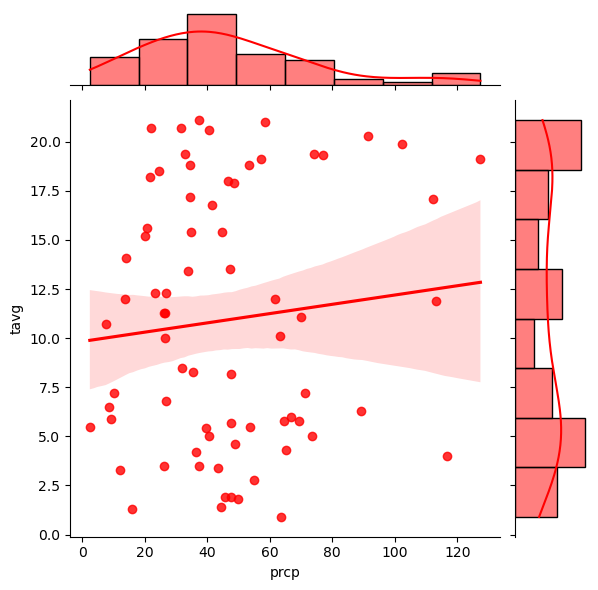

In [165]:
sns.jointplot(data=data, y="tavg", x="prcp", kind="reg" , color = "red")

```Use  KDE plot to visualize density between temperature and sunshine duration.```

<Axes: xlabel='tavg', ylabel='tsun'>

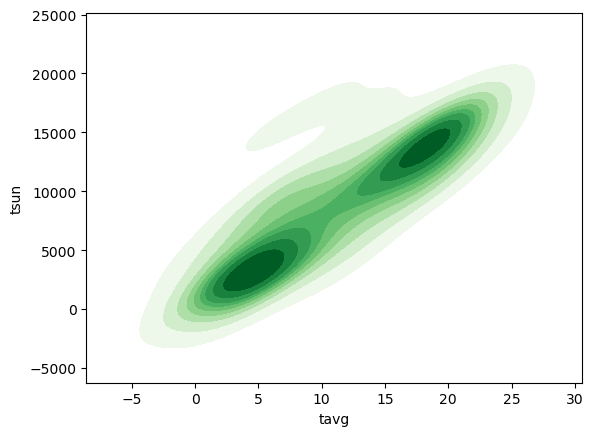

In [166]:
sns.kdeplot(data = data , x="tavg" , y = "tsun" ,cmap = "Greens" , fill = True)

` q26) Create a clustermap based on correlations among variables. `

In [167]:
corr = data.corr(numeric_only = True)

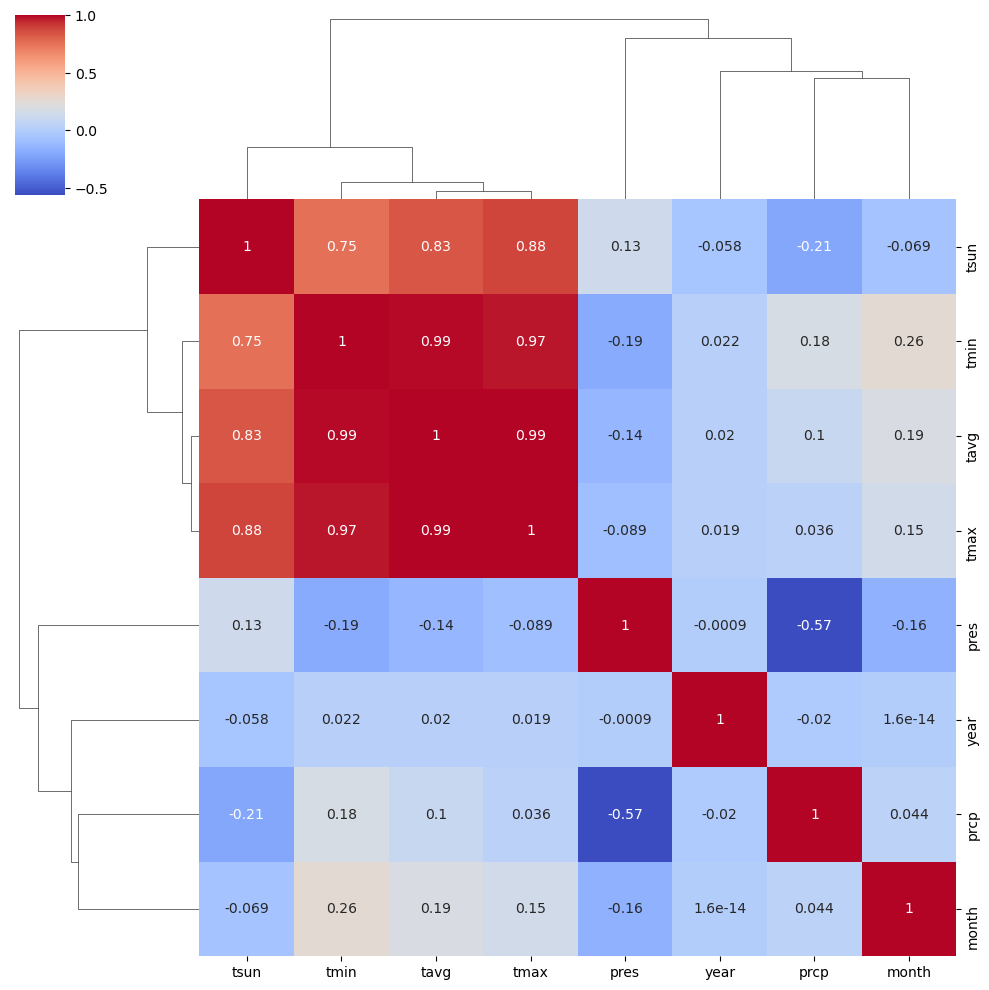

In [168]:
sns.clustermap(data = corr , annot = True , cmap="coolwarm")

`Q28 ) create voilin plots`

/tmp/ipykernel_8703/3886552105.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = data, x = "tavg", palette= "coolwarm")


<Axes: xlabel='tavg'>

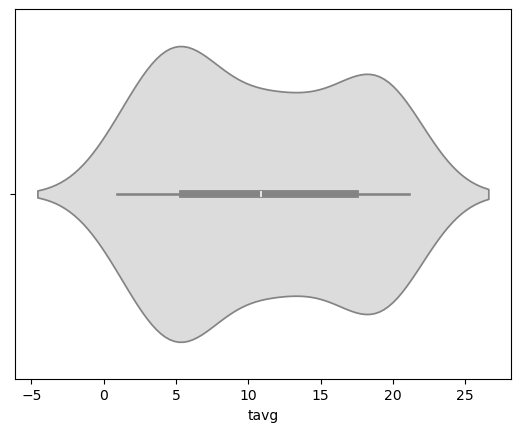

In [169]:
sns.violinplot(data = data, x = "tavg", palette= "coolwarm")

/tmp/ipykernel_8703/1391035090.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = data, x = "prcp" , palette="magma")


<Axes: xlabel='prcp'>

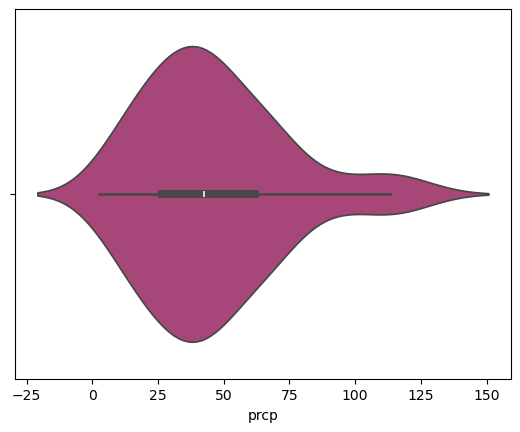

In [170]:
sns.violinplot(data = data, x = "prcp" , palette="magma")

/tmp/ipykernel_8703/366264692.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data= data , x = "pres" , palette= "viridis")


<Axes: xlabel='pres'>

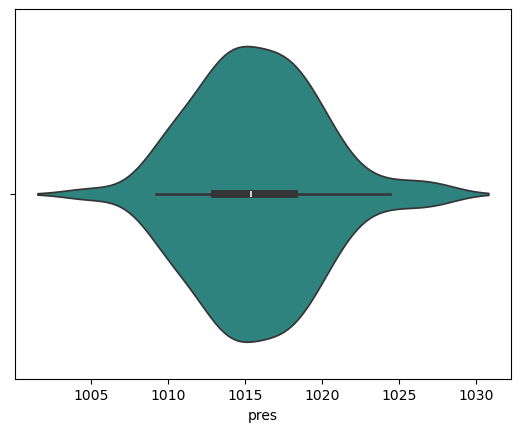

In [171]:
sns.violinplot(data= data , x = "pres" , palette= "viridis")